In [1]:
import numpy as np
import pandas as pd
from matplotlib import rcParams
import matplotlib.pyplot as plt
import os
import xarray as xr

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

## 1. Sensitivity of the Q10 function to parameters

Bigger denominators - less sensitive to temperature. 
That's great, meaning that to make shrubs uptake more at higher temperatures, I just give them a smaller denominator. 
Set shrub = 4, tree = 6 for trial

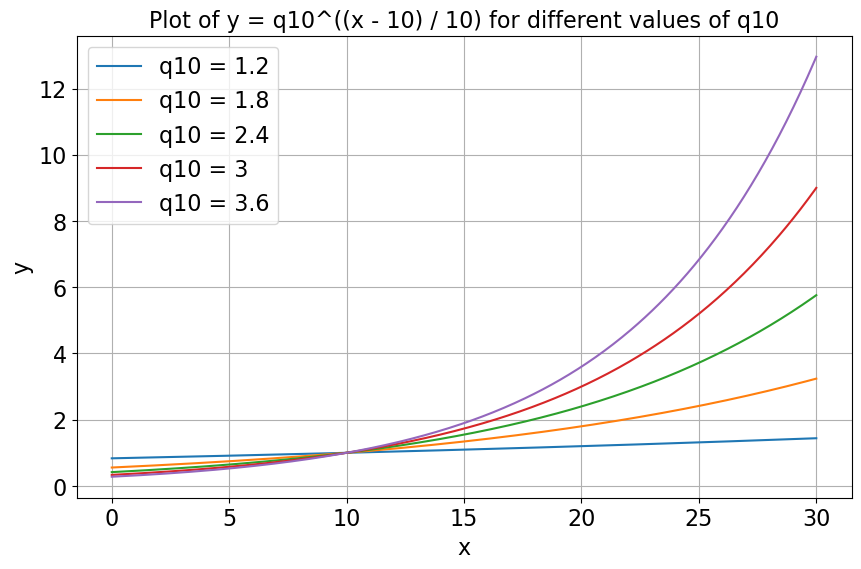

In [2]:
# Define the function with an additional parameter z
def f(x, q10, z, tbase):
    return q10 ** ((x - tbase) / z)

#
tbase = 10
z = 10 # z_vlaues = [10, 16, 20]
q10_values = [1.2, 1.8, 2.4, 3, 3.6]

# Generate x values
x = np.linspace(0, 30, 400)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
for q10 in q10_values:
    y = f(x, q10, z, tbase)
    plt.plot(x, y, label=f'q10 = {q10}')

plt.title(f'Plot of y = q10^((x - {tbase}) / {z}) for different values of q10')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 2. Sensitivity of the Michaelis-Menten function to parameters

sminn_vr: gN m-3, soil mineral N

* defined by: `col_ns%sminn_vr(c,j) = col_ns%smin_nh4_vr(c,j) + col_ns%smin_no3_vr(c,j)`

sminp_vr: gP m-3, soil mineral P

* defined by: `this%sminp_vr(c,j) = this%solutionp_vr(c,j) + this%labilep_vr(c,j) + this%secondp_vr(c,j)`

This one can wait until last. As controlled by the affinity parameter, the uptake can only be uniformly higher or lower. Hence this may not be useful for temperature-dependent competitive advantages. 

Text(0.5, 1.0, 'Michalis-Menten factor P')

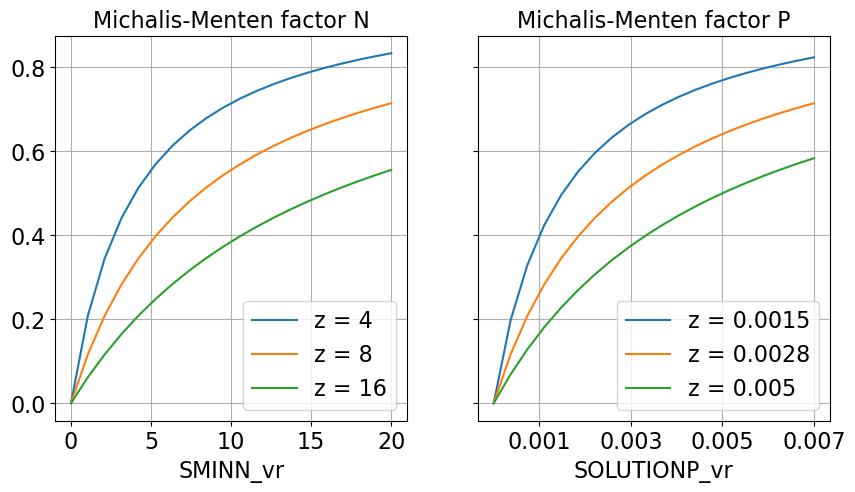

In [68]:
# Define the function with an additional parameter z
def g(x, z):
    return x / (z + x)

fig, axes = plt.subplots(1, 2, figsize = (10, 5), sharey = True)

ax = axes.flat[0]
x = np.linspace(0, 20, 20)
z_values = [4, 8, 16]
for z in z_values:
    y = g(x, z)
    ax.plot(x, y, label=f'z = {z}')
ax.set_xlabel('SMINN_vr')
ax.legend()
ax.grid(True)
ax.set_title('Michalis-Menten factor N')

ax = axes.flat[1]
x = np.linspace(0, 0.007, 20)
z_values = [0.0015, 0.0028, 0.005]
for z in z_values:
    y = g(x, z)
    ax.plot(x, y, label=f'z = {z}')
ax.set_xticks([0.001, 0.003, 0.005, 0.007])
ax.set_xlabel('SOLUTIONP_vr')
ax.legend()
ax.grid(True)
ax.set_title('Michalis-Menten factor P')

## 3. Stem allocation function

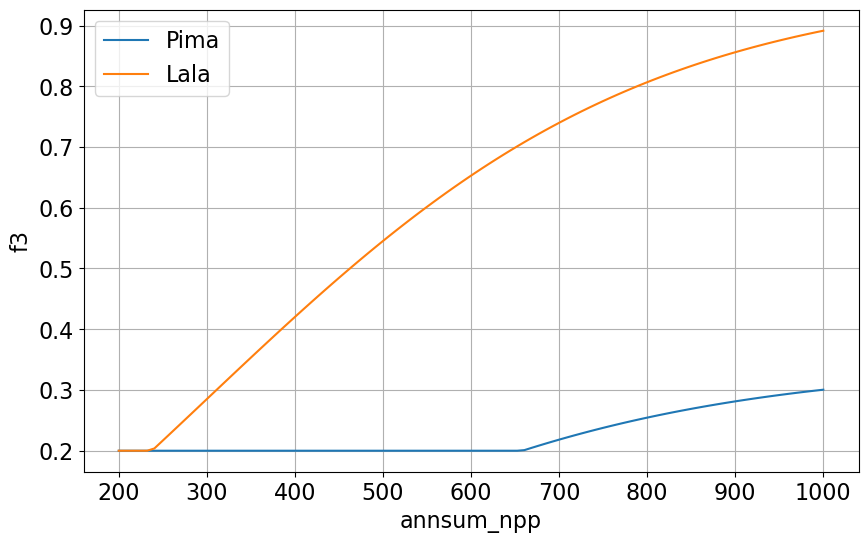

In [4]:
def f3(annsum_npp, stem_leaf):
    return np.maximum((-stem_leaf*2.7)/(1+np.exp(-0.004*(annsum_npp - 300))) - 0.4, 0.2)


# Generate x values
x = np.linspace(200, 1000, 100)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
stem_leaf = [-0.275204284477043, -0.507394631180568]
for z, name in zip(stem_leaf,['Pima','Lala']):
    y = f3(x, z)
    plt.plot(x, y, label=name)
plt.legend()
plt.xlabel('annsum_npp')
plt.ylabel('f3')
plt.legend()
plt.grid(True)
plt.show()

## 4. Relationship between stem_root and belowground-to-aboveground NPP ratio - they are different

$$
\frac{\text{LEAF} + \text{STEM}}{\text{FROOT} + \text{CROOT}} = \frac{1 + \frac{\text{STEM}}{\text{LEAF}}}{\frac{\text{FROOT}}{\text{LEAF}} + \frac{\text{CROOT}}{\text{STEM}} \frac{\text{STEM}}{\text{LEAF}} }
$$

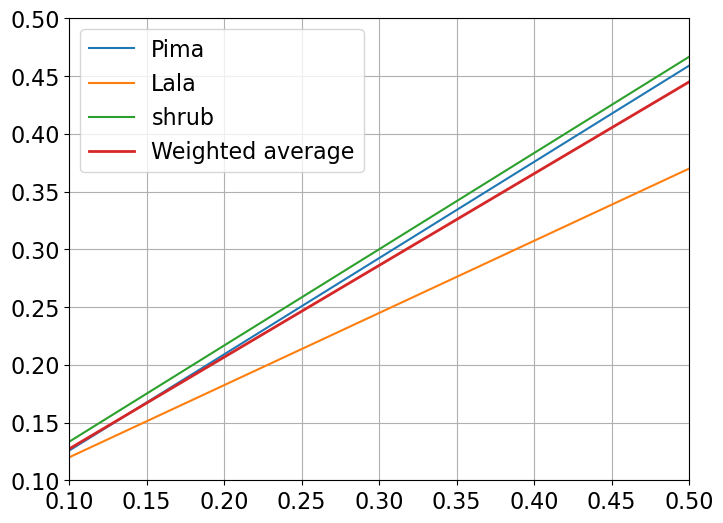

In [5]:
def bg_to_ag(froot_leaf, stem_leaf, croot_stem):
    return (froot_leaf + stem_leaf * croot_stem) / (1 + stem_leaf)

froot_leaf = np.linspace(0.1, 0.5, 20)

plt.figure(figsize = (8, 6))
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.254), label = 'Pima')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.6, 0.1529), label = 'Lala')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3), label = 'shrub')

plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3)*0.25/0.75 + \
         bg_to_ag(froot_leaf, 0.6, 0.1529) * 0.14/0.75 + \
         bg_to_ag(froot_leaf, 0.2, 0.254) * 0.36/0.75, label = 'Weighted average', lw = 2)

plt.legend()
plt.xlim([0.1, 0.5])
plt.ylim([0.1, 0.5])
plt.grid(True)

## 5. CNP allometry equations


$$\text{callo} = (1 + \text{grperc}) \times (1 + \text{froot\_leaf} + \text{stem\_leaf} \times (1 + \text{croot\_stem}))$$

$$\text{nallo} = \frac{1}{\text{leafcn}} + \frac{\text{froot\_leaf}}{\text{frootcn}} + \frac{\text{stem\_leaf} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcn}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcn}}$$

$$\text{pallo} = \frac{1}{\text{leafcp}} + \frac{\text{froot\_leaf}}{\text{frootcp}} + \frac{\text{\text{stem\_leaf}} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcp}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcp}}$$

In [6]:
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'inputdata', 'atm', 'datm7', 
                                  'CLM1PT_data', 'SPRUCE_data', 
                                  'clm_params_SPRUCE_20231120_spruceroot.nc_CNP'))

In [7]:
callo = (1 + hr['grperc']) * (1 + hr['froot_leaf'] + hr['stem_leaf'] * (1 + hr['croot_stem']))
nallo = 1 / hr['leafcn'] + hr['froot_leaf'] / hr['frootcn'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcn'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcn']
pallo = 1 / hr['leafcp'] + hr['froot_leaf'] / hr['frootcp'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcp'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcp']

print(np.around( (callo / nallo).values, 4 )[[2,3,11]])
print(np.around( (callo / pallo).values, 5 )[[2,3,11]])

[44.4534 42.4152 51.7717]
[650.7189  570.26833 843.14325]


## 7. CPOOL Excess respiration function

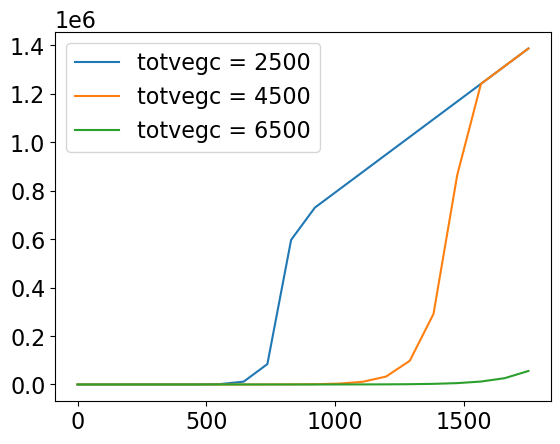

In [8]:
cpool = np.linspace(0, 1750, 20)
for totvegc in [2500, 4500, 6500]:
    y = cpool * np.exp( (np.minimum(cpool/totvegc, 0.3335) - 0.2) / 0.02)
    plt.plot(cpool, y, label = f'totvegc = {totvegc}')
plt.legend()

## 8. Water table depth control on roots

In [9]:
# Read observed water table, ignore surface water
zwt_obs = {}
for plot in [10,11,13,16,17,19,20,4,6,7,8]:
    filename = os.path.join(os.environ['E3SM_ROOT'], 'inputdata', 'atm',
                            'datm7', 'CLM1PT_data', 'SPRUCE_data',
                            f'plot{plot:02d}', 'all_hourly.nc')
    hr = xr.open_dataset(filename)

    datetime = pd.DatetimeIndex(
        [pd.Timestamp(year = t.year, month = t.month, 
                      day = t.day) for t in hr['DTIME'].to_index()]
    )
    temp = pd.Series(hr['ZWT'].values.reshape(-1), index = datetime)

    # skip H2OSFC
    zwt_obs[('hummock', str(plot))] = temp # + 0.15
    zwt_obs[('hollow', str(plot))] = temp

    hr.close()
zwt_obs = pd.DataFrame(zwt_obs)

In [10]:
# Read simulated water table
# Plot water table depth
data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output',
                                'extract', '20240311', 'analysis_ts.csv'),
                   index_col = 0, header = [0,1,2,3], parse_dates = True)
zwt_sim = data.loc[(data.index.month >= 5) & (data.index.month <= 10), (slice(None), 'ZWT', '0')]
zwt_sim.columns = zwt_sim.columns.droplevel([1,2]).reorder_levels([1,0])

In [11]:
# all-average water table is ~level with hollow
zwt_sim.loc[:, (slice(None), '7')].mean()

topo     plot
hummock  7      -0.041058
hollow   7      -0.036618
dtype: float64

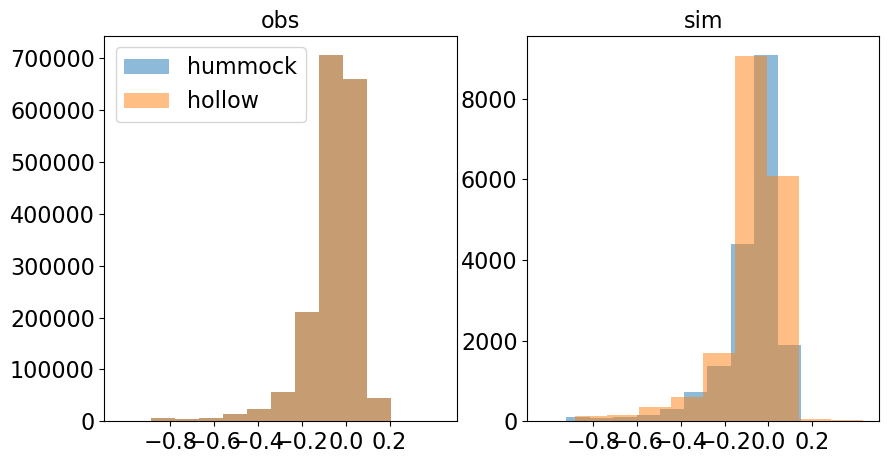

In [12]:
# historical distribution of the observed and simulated ZW
# Note I've already inverted the data to deeper = more negative in extracting the simulation files
fig, axes = plt.subplots(1, 2, figsize = (10, 5), sharex = True)
ax = axes.flat[0]
ax.hist(zwt_obs.loc[:, 'hummock'].values.reshape(-1), alpha = 0.5, label = 'hummock')
ax.hist(zwt_obs.loc[:, 'hollow'].values.reshape(-1), alpha = 0.5, label = 'hollow')
ax.set_title('obs')
ax.legend()
ax.set_xticks(np.arange(-0.8, 0.3, 0.2))
ax = axes.flat[1]
ax.hist(zwt_sim.loc[:, 'hummock'].values.reshape(-1), alpha = 0.5, label = 'hummock')
ax.hist(zwt_sim.loc[:, 'hollow'].values.reshape(-1), alpha = 0.5, label = 'hollow')
ax.set_title('sim')
ax.set_xticks(np.arange(-0.8, 0.3, 0.2))

Text(0.5, 1.0, 'sim')

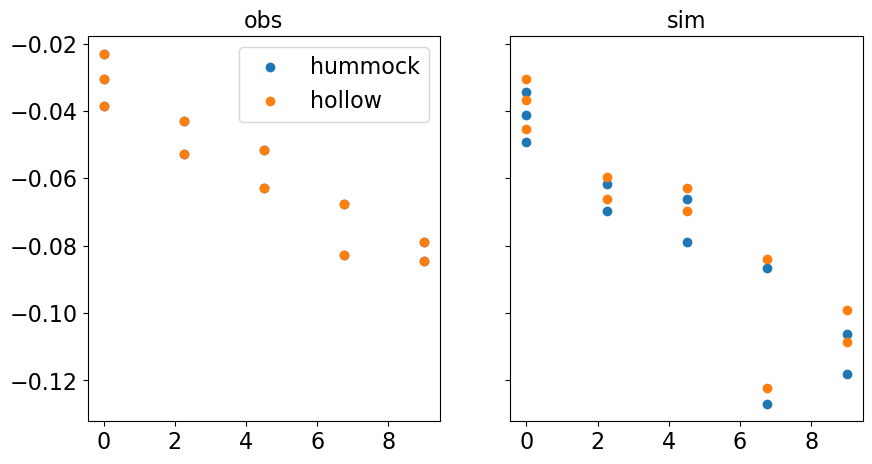

In [13]:
# sensitivity of ZWT to warming
from utils.constants import chamber_levels

zwt_obs_mean = zwt_obs.mean().unstack().T
zwt_sim_mean = zwt_sim.mean().unstack().T

temperature = [chamber_levels[f'{int(i):02d}'][0] for i in zwt_obs_mean.index]

fig, axes = plt.subplots(1, 2, figsize = (10, 5), sharex = True, sharey = True)
ax = axes.flat[0]
ax.plot(temperature, zwt_obs_mean['hummock'], 'o', label = 'hummock')
ax.plot(temperature, zwt_obs_mean['hollow'], 'o', label = 'hollow')
ax.set_title('obs')
ax.legend()
ax = axes.flat[1]
ax.plot(temperature, zwt_sim_mean['hummock'], 'o', label = 'hummock')
ax.plot(temperature, zwt_sim_mean['hollow'], 'o', label = 'hollow')
ax.set_title('sim')

"plt.figure(figsize = (8, 6))\nzwt = np.linspace(-0.8, 0.4) # more negative -> deeper underground\nfor slope, name in zip([1.4, 1.4, -1.4], ['Spruce', 'Tamarack', 'Shrub']):\n    if name == 'Spruce':\n        baseline = 0.2\n    elif name == 'Tamarack':\n        baseline = 0.2\n    elif name == 'Shrub':\n        baseline = 0.8\n    plt.plot(zwt, np.minimum(1, 10**(slope*(-zwt - 0.01)) * baseline), label = name)\nplt.legend()\nplt.xlabel('Water table depth (- for deeper) (m)', fontsize = 20)\nplt.ylabel('Fungi inhibition', fontsize = 20)"

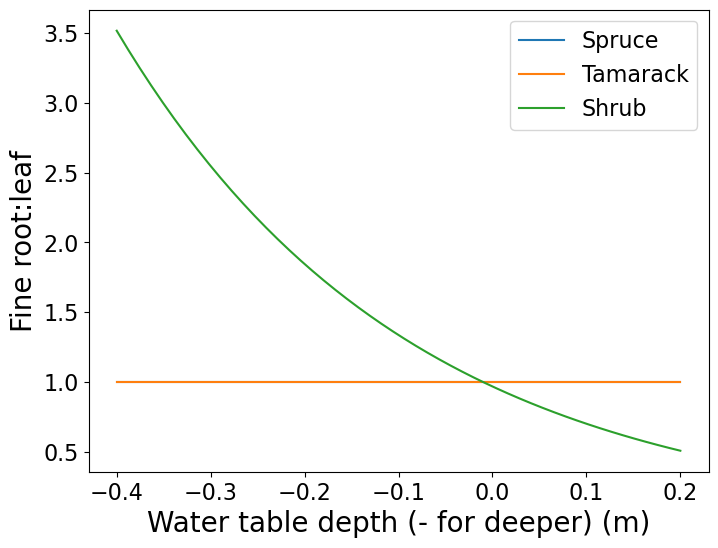

In [14]:
plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.4, 0.2) # more negative -> deeper underground
for slope, name in zip([0, 0., 1.4], ['Spruce', 'Tamarack', 'Shrub']):
    #if name == 'Spruce':
    #    froot_leaf = 0.3
    #elif name == 'Tamarack':
    #    froot_leaf = 0.38
    #elif name == 'Shrub':
    #    froot_leaf = 0.3
    froot_leaf = 1
    plt.plot(zwt, 10**(slope*(-zwt - 0.01)) * froot_leaf, label = name) #label = f'{name}={slope}')
plt.legend()
plt.xlabel('Water table depth (- for deeper) (m)', fontsize = 20)
plt.ylabel('Fine root:leaf', fontsize = 20)


"""plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.8, 0.4) # more negative -> deeper underground
for slope, name in zip([1.4, 1.4, -1.4], ['Spruce', 'Tamarack', 'Shrub']):
    if name == 'Spruce':
        baseline = 0.2
    elif name == 'Tamarack':
        baseline = 0.2
    elif name == 'Shrub':
        baseline = 0.8
    plt.plot(zwt, np.minimum(1, 10**(slope*(-zwt - 0.01)) * baseline), label = name)
plt.legend()
plt.xlabel('Water table depth (- for deeper) (m)', fontsize = 20)
plt.ylabel('Fungi inhibition', fontsize = 20)"""

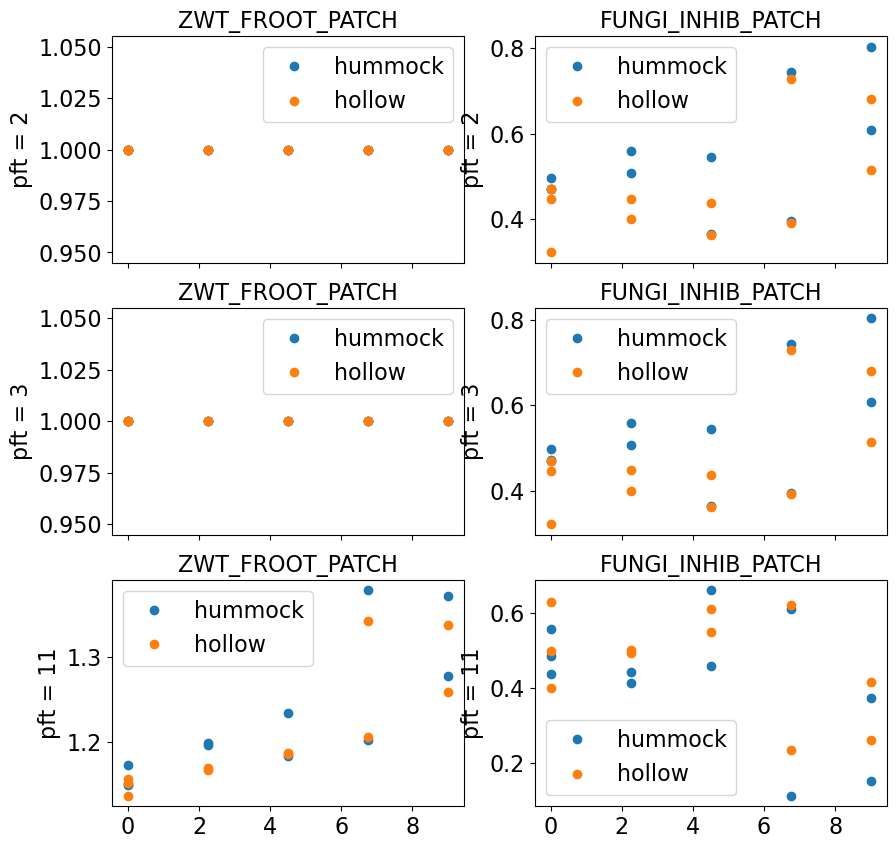

In [15]:
# sensitivity of dynamic fine root allocation to warming
prefix = '20240311'
data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output',
                            'extract', prefix, 'analysis_ts.csv'),
                index_col = 0, header = [0,1,2,3], parse_dates = True)
data = data.loc[(data.index.month >= 5) & (data.index.month <= 10), 
                (slice(None), ['ZWT_FROOT_PATCH', 'FUNGI_INHIB_PATCH'])]
data = data.mean(axis = 0).unstack().unstack().unstack()
data.columns = data.columns.reorder_levels([2, 1, 0])


temperature = [chamber_levels[f'{int(i):02d}'][0] for i in data.index]

fig, axes = plt.subplots(3, 2, figsize = (10, 10), sharex = True)
for i, var in enumerate(['ZWT_FROOT_PATCH', 'FUNGI_INHIB_PATCH']):
    for j, pft in enumerate(['2','3','11']):
        ax = axes[j, i]
        ax.plot(temperature, data.loc[:, (var,pft,'hummock')], 'o', label = 'hummock')
        ax.plot(temperature, data.loc[:, (var,pft,'hollow')], 'o', label = 'hollow')

        ax.set_title(var)
        ax.set_ylabel(f'pft = {pft}')
        ax.legend()

## 9. Moisture control on BTRAN

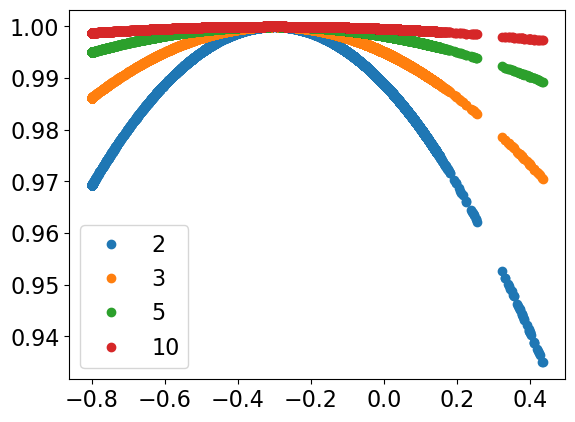

In [16]:
# > 0 = surface water
# < 0 = below soil column
waterlevel_threshold = -0.8
waterlevel_opt = -0.3

x = zwt_sim.values.reshape(-1)
x[x < waterlevel_threshold] = waterlevel_threshold

# tamarack should be the most tolerant of flooding condition
# shrub is probably not tolerant, but has less deep roots
# let's keep the function for now and do a sensitivity analysis?
for waterlevel_tol in [2, 3, 5, 10]:
    floodf = np.exp(-0.5 * ((x - waterlevel_opt) / waterlevel_tol)**2)
    plt.plot(x, floodf, 'o', label = waterlevel_tol)
plt.legend()

## 10. Water table and nutrient control on fungal inhibition

Hand calculate for each chamber and plot

### 10.1 Test using growing season average ZWT and nutrient levels

In [17]:
from utils.constants import chamber_levels

prefix = '20240311'
data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output',
                            'extract', prefix, 'analysis_ts.csv'),
                index_col = 0, header = [0,1,2,3], parse_dates = True)

# for temperature - use annual mean
data_ = data.loc[:, (slice(None), 'TBOT')]
data_ = data_.resample('1Y').mean()
data_.columns = data_.columns.reorder_levels([1,2,3,0])
data_.index = data_.index.year
tbot = data_.loc[:, ('TBOT','0')].stack()

## skip year 2015 because bad
#tbot = tbot.loc[tbot.index.get_level_values(0) != 2015, :]

# for other variables - tested growing season mean but 
# annual average also works fine
data = data.loc[:, # (data.index.month >= 5) & (data.index.month <= 10), 
                (slice(None), ['ZWT','SMINN_vr_ROOTFR', 'SOLUTIONP_vr_ROOTFR'])]
data = data.resample('1Y').mean()
data.columns = data.columns.reorder_levels([1,2,3,0])
data.index = data.index.year

# skip year 2015 because bad
## data = data.loc[data.index != 2015, :]

zwt = data.loc[:, ('ZWT','0')].stack()
sminn = data.loc[:, 'SMINN_vr_ROOTFR'].loc[:, ['2','3','11']].stack()
sminp = data.loc[:, 'SOLUTIONP_vr_ROOTFR'].loc[:, ['2','3','11']].stack()

/tmp/ipykernel_2644897/416385564.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  zwt = data.loc[:, ('ZWT','0')].stack()


<Axes: xlabel='None,plot'>

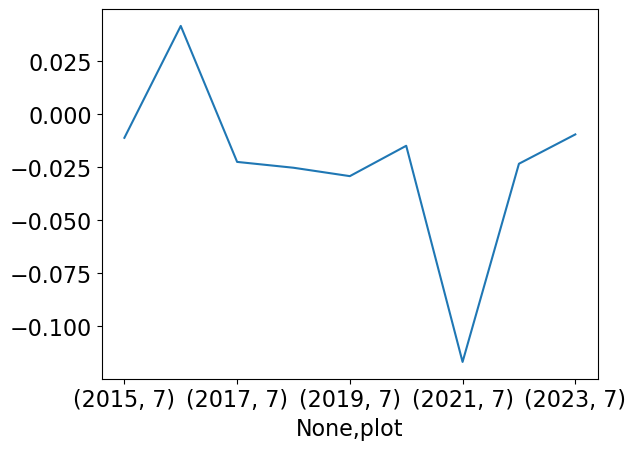

In [18]:
zwt.loc[(slice(None), '7'), 'hollow'].plot()

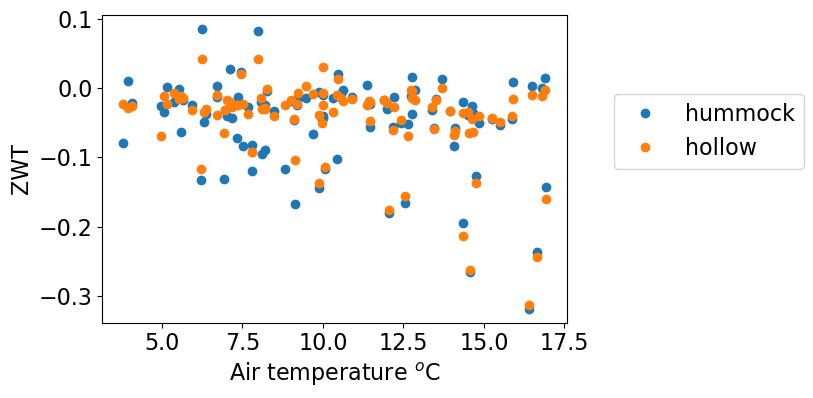

In [19]:
fig, ax = plt.subplots(figsize = (6, 4), sharex = True)
ax.plot(tbot.loc[:,'hummock'], zwt.loc[:, 'hummock'], 'o', label = 'hummock')
ax.plot(tbot.loc[:,'hollow'], zwt.loc[:, 'hollow'], 'o', label = 'hollow')
ax.set_xlabel('Air temperature $^o$C')
ax.set_ylabel(f'ZWT')
ax.legend(loc = (1.1, 0.5))

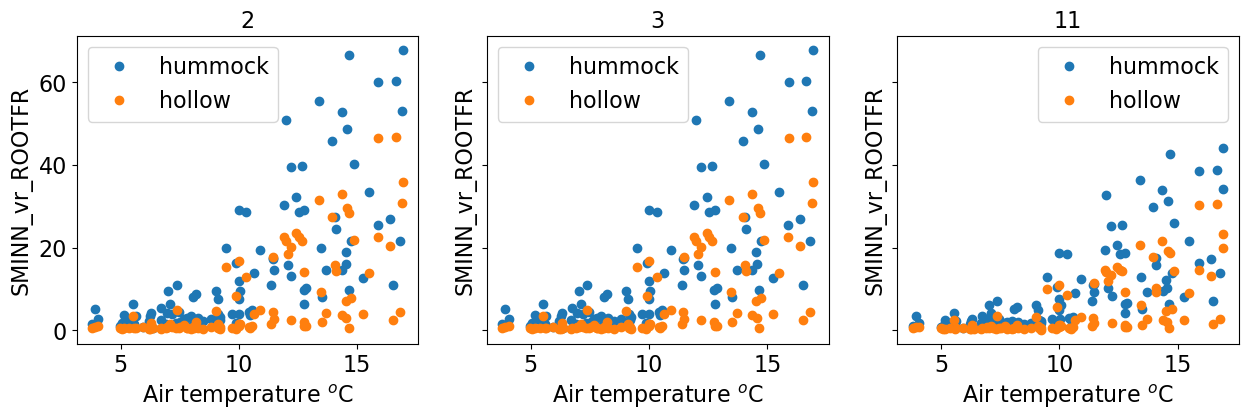

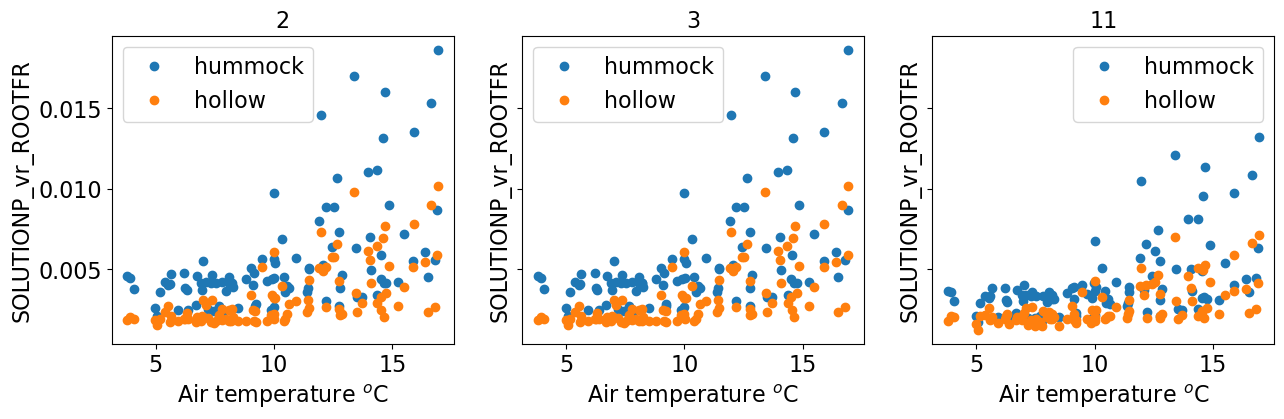

In [20]:
for varname, var in zip(['SMINN_vr_ROOTFR', 'SOLUTIONP_vr_ROOTFR'], 
                        [sminn, sminp]):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, pft in enumerate(['2','3','11']):
        ax = axes.flat[i]

        ax.plot(tbot.loc[:,'hummock'], var.loc[:, (str(pft), 'hummock')], 'o', label = 'hummock')
        ax.plot(tbot.loc[:,'hollow'], var.loc[:, (str(pft), 'hollow')], 'o', label = 'hollow')

        ax.set_title(pft)
        ax.set_xlabel('Air temperature $^o$C')
        ax.set_ylabel(varname)
        ax.legend()

Equation is 

$M_{fungi,j} = \min ( \exp (a_j Z_w - \sum_{i} z_{i,j} \left[ \frac{(N_{conc,i,NH_4^+} + N_{conc,i,NO_3^-} )}{b_j} + \frac{N_{conc,i,P}}{c_j} \right] ), 1)$

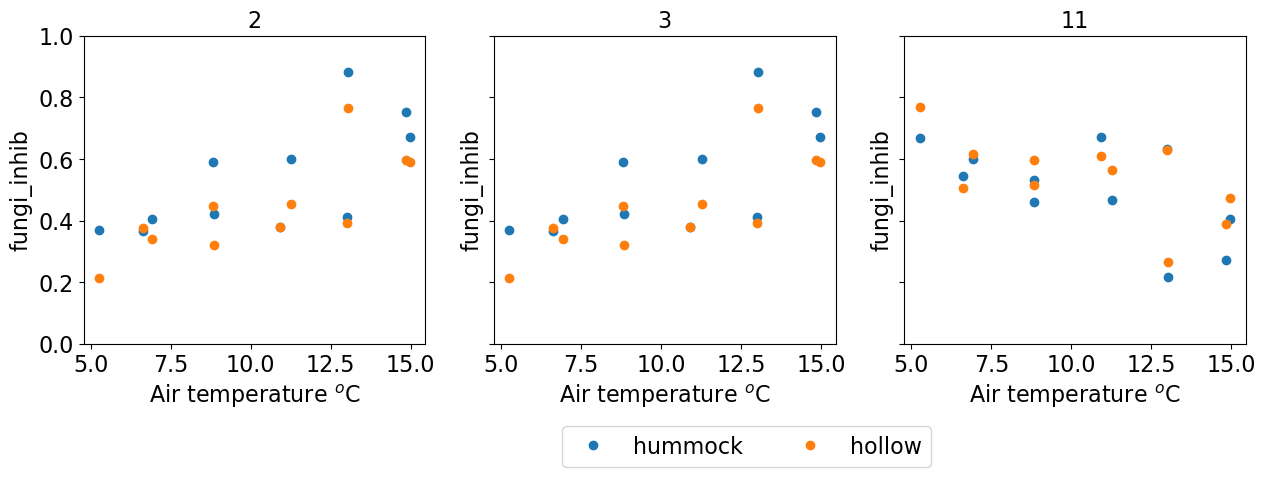

In [21]:
fungi_inhib = pd.DataFrame(np.nan, index = sminn.index, columns = sminn.columns)


# use chamber as the index, not air temperature
# because the two are slightly misaligned
temperature = [chamber_levels[f'{int(i):02d}'][0] for i in sminp.index.get_level_values(1)]


fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
for i, pft in enumerate(['2','3','11']):
    ax = axes.flat[i]

    c = 0.7
    d = 1/60
    e = 1/0.016

    for col in ['hummock', 'hollow']:
        if pft == '11':
            a = 120
            zwt_term = 3 + a*(zwt.loc[:, col]) # equation in ELM also converted to relative to hollow surface, negative = downwards
        else:
            a = -85
            zwt_term = -3.5 + a*(zwt.loc[:, col])

        fungi_inhib.loc[:, (str(pft), col)] = \
           np.minimum( np.exp(zwt_term) * \
                       (c + np.minimum(d * sminn.loc[:, (str(pft), col)],
                                       e * sminp.loc[:, (str(pft), col)])),
                      1 )

        x = temperature[::5]
        x = x + np.random.rand(len(x)) * 0.5 - 0.25 # jitter
        x = tbot.loc[:, col].unstack().mean(axis = 0)
        y = fungi_inhib.loc[:, (str(pft), col)].unstack().mean(axis = 0)
        ax.plot(x, y, 'o', label = col)

    ax.set_title(pft)
    ax.set_xlabel('Air temperature $^o$C')
    ax.set_ylabel('fungi_inhib')
    ax.set_ylim([0,1])
ax.legend(loc = (-1, -0.4), ncol = 2)

### 10.2 Test using 60-day rolling average ZWT and nutrient levels

In [22]:
from utils.constants import chamber_levels

prefix = '20231113_4'
data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output',
                            'extract', prefix, 'analysis_ts.csv'),
                index_col = 0, header = [0,1,2,3], parse_dates = True)

# for temperature - use annual mean
data_ = data.loc[:, (slice(None), 'TBOT')]
data_ = data_.resample('1YS').mean()
data_.columns = data_.columns.reorder_levels([1,2,3,0])
data_.index = data_.index.year
tbot = data_.loc[:, ('TBOT','0')].stack()

# skip year 2015 because bad
tbot = tbot.loc[tbot.index.get_level_values(0) != 2015, :]

# for other variables - annual mean # 60-day rolling averages
#data = data.loc[(data.index.month >= 5) & (data.index.month <= 10), 
#                (slice(None), ['ZWT','SMINN_vr_ROOTFR', 'SOLUTIONP_vr_ROOTFR'])]
data = data.loc[:, (slice(None), ['ZWT','SMINN_vr_ROOTFR', 'SOLUTIONP_vr_ROOTFR'])]
data.columns = data.columns.reorder_levels([1,2,3,0])
# data = data.rolling(window=60).mean()
data = data.resample('1YS').mean()

# skip year 2015 because bad
data = data.loc[data.index.year != 2015, :]

zwt = data.loc[:, ('ZWT','0')].stack()
sminn = data.loc[:, 'SMINN_vr_ROOTFR'].loc[:, ['2','3','11']].stack()
sminp = data.loc[:, 'SOLUTIONP_vr_ROOTFR'].loc[:, ['2','3','11']].stack()

/tmp/ipykernel_2644897/525466657.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  zwt = data.loc[:, ('ZWT','0')].stack()


In [23]:
fungi_inhib = pd.DataFrame(np.nan, index = sminn.index, columns = sminn.columns)
for i, pft in enumerate(['2','3','11']):
    c = 0.7
    d = 1/80
    e = 1/0.016

    for col in ['hummock', 'hollow']:
        if pft == '11':
            a = 40
            b = 1
        else:
            a = -30
            b = -2
        fungi_inhib.loc[:, (str(pft), col)] = \
           np.minimum( np.exp(b + a*zwt.loc[:, col]) * \
                       (c + np.minimum(d * sminn.loc[:, (str(pft), col)],
                                       e * sminp.loc[:, (str(pft), col)])),
                      1 )
#fungi_inhib = fungi_inhib.unstack()
#fungi_inhib = fungi_inhib.loc[(fungi_inhib.index.month >= 5) & (fungi_inhib.index.month <= 10), :]
fungi_inhib_annual_mean = fungi_inhib # .resample('1Y').mean().stack()

In [24]:
"""fig, axes = plt.subplots(6, 2, figsize = (15, 15), sharex = True, sharey = True)
for j, plot in enumerate(fungi_inhib.columns.levels[2]):
    ax = axes.flat[j]
    for i, pft in enumerate(['2','3','11']):
        for k, col in enumerate(['hummock', 'hollow']):
            ax.plot(fungi_inhib.index, fungi_inhib.loc[:, (str(pft),col,str(plot))], 'o')
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_title(f'plot{plot}')"""

"fig, axes = plt.subplots(6, 2, figsize = (15, 15), sharex = True, sharey = True)\nfor j, plot in enumerate(fungi_inhib.columns.levels[2]):\n    ax = axes.flat[j]\n    for i, pft in enumerate(['2','3','11']):\n        for k, col in enumerate(['hummock', 'hollow']):\n            ax.plot(fungi_inhib.index, fungi_inhib.loc[:, (str(pft),col,str(plot))], 'o')\n    plt.setp(ax.get_xticklabels(), rotation = 90)\n    ax.set_title(f'plot{plot}')"

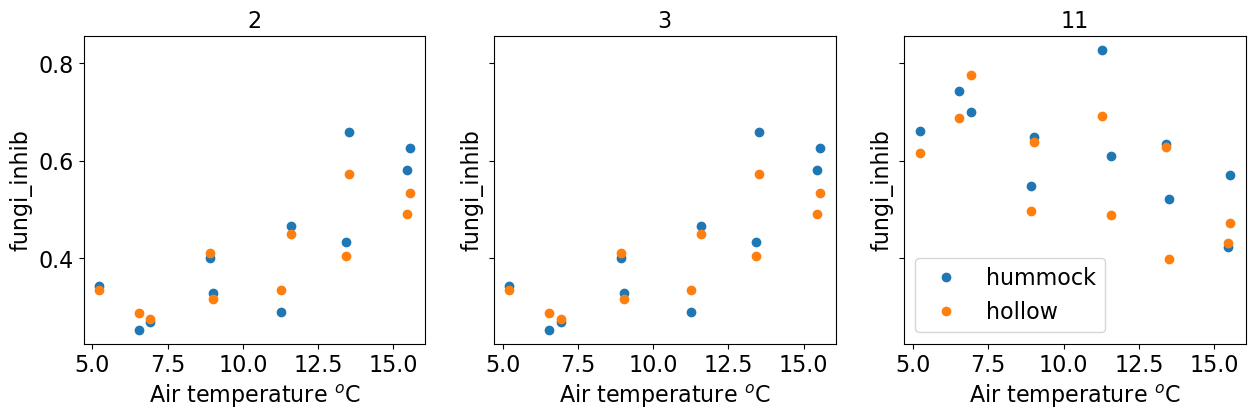

In [25]:
# plot the relationship with air temperature
temperature = [chamber_levels[f'{int(i):02d}'][0] for i in \
               fungi_inhib_annual_mean.index.get_level_values(1)]

fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
for i, pft in enumerate(['2','3','11']):
    ax = axes.flat[i]
    for col in ['hummock', 'hollow']:
        # x = temperature[::5] 
        x = tbot.loc[:, col].unstack().mean(axis = 0)
        y = fungi_inhib_annual_mean.loc[:, (str(pft), col)].unstack().mean(axis = 0)
        ax.plot(x, y, 'o', label = col)
    ax.set_title(pft)
    ax.set_xlabel('Air temperature $^o$C')
    ax.set_ylabel('fungi_inhib')
ax.legend()

## 11. FPG & FPG_P control on nutrient uptake

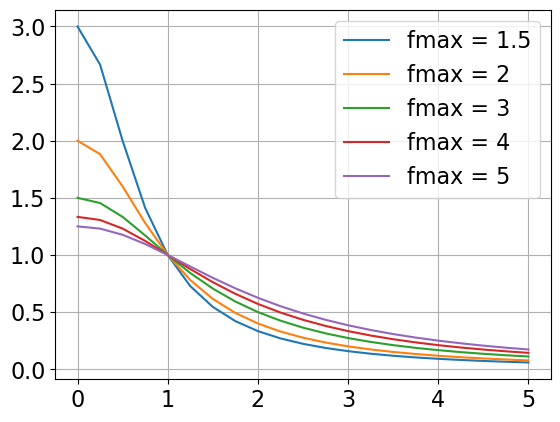

In [26]:
fpg = np.linspace(1e-5, 5, 21)
for fmax in [1.5, 2, 3, 4, 5]:
    plt.plot(fpg, fmax/(fmax-1+fpg**2), label = f'fmax = {fmax}')
#plt.plot(fpg, 3 - 1.5*fpg)
plt.grid(True)
plt.legend()